In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from mpl_toolkits.mplot3d import Axes3D

from tqdm.notebook import tqdm

# MedMNISTの読み込み用
import medmnist
from medmnist import INFO

In [2]:
# ==========================================
# 1. データセットの準備 (OrganMNIST 3D)
# ==========================================
data_flag = 'organmnist3d'  # 3Dの臓器軸位スライスデータ（28x28x28）
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# データの取得（自動ダウンロードされます）
train_dataset = DataClass(split='train', download=True)
test_dataset = DataClass(split='test', download=True)

In [3]:
print(info["label"]["0"])

liver


In [4]:
# PyTorchのDataLoader形式に変換（Tensor化と正規化）
# def transform_3d(x):
#     # [Depth, Height, Width] -> [1, Depth, Height, Width] にして 0-1 正規化
#     tensor = torch.tensor(x, dtype=torch.float32)
#     return tensor / 255.0

def transform_3d_resized(x):
    # [Depth, Height, Width] -> [1, 1, Depth, Height, Width] (バッチ次元を擬似的に追加)
    tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
    
    # トリリニア補間で3軸とも2倍に拡大
    tensor_resized = F.interpolate(tensor, scale_factor=5.0, mode='trilinear', align_corners=False)
    
    # [1, 56, 56, 56] に戻して 0-1 正規化
    return tensor_resized.squeeze(0) / 255.0

train_dataset.transform = transform_3d_resized
test_dataset.transform = transform_3d_resized

train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1, shuffle=True) # 可視化用にbatch=1

n_classes = len(info['label']) # クラス数 (OrganMNIST 3D は 11 クラス)

In [5]:
# ==========================================
# 2. 3D-CNN モデルの定義
# ==========================================
class MedicalCNN3D(nn.Module):
    def __init__(self, num_classes):
        super(MedicalCNN3D, self).__init__()
        self.conv1 = nn.Conv3d(1, 16, kernel_size=3, stride=2)
        self.pool1 = nn.MaxPool3d(2) # 28 -> 14
        
        # ターゲットとする最終畳み込み層
        self.target_conv = nn.Conv3d(16, 32, kernel_size=3, stride=2)
        self.pool2 = nn.MaxPool3d(2) # 14 -> 7
        
        self.fc1 = nn.Linear(32*8*8*8, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.target_conv(x)
        x = self.pool2(F.relu(x))
        # print(x.shape)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [6]:
model = MedicalCNN3D(num_classes=n_classes)

In [7]:
# ==========================================
# 3. 簡易トレーニング
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_training = 10

model.train()
for i in tqdm(range(num_training)):
    for batch_idx, (inputs, targets) in tqdm(enumerate(train_loader)):
        targets = targets.squeeze().long() # 形状の調整
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        # if batch_idx >= 20: break # 時間短縮のため途中で打ち切り

  0%|          | 0/10 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

KeyboardInterrupt: 

In [8]:
# ==========================================
# 4. 3D Grad-CAM++ のクラス定義（前述のものを流用）
# ==========================================
class GradCAMPlusPlus3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output): self.activations = output
        def backward_hook(module, grad_input, grad_output): self.gradients = grad_output[0]
        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_backward_hook(backward_hook))

    def generate_cam(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
        
        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        # フックから特徴量と勾配を取得
        activations = self.activations.detach()
        gradients = self.gradients.detach()

        # 勾配の1乗、2乗、3乗を計算
        grads_power_1 = gradients
        grads_power_2 = gradients ** 2
        grads_power_3 = gradients ** 3

        # =================================================================
        # 修正箇所: 3D Grad-CAM++ の重み (alpha) 計算
        # =================================================================
        # 空間次元 (2, 3, 4) の sum を集約せず、各ボクセルの activations を直接使用します
        aij = 2 * grads_power_2
        bijk = grads_power_3 * activations  
        
        # 分母の打ち消し合いと0除算を防ぐため、絶対値と微小値を適用
        denominator = torch.abs(aij + bijk) + 1e-10

        # 各ボクセル位置 [i, j, k] ごとの alpha を計算
        alpha = grads_power_2 / denominator
        
        # alpha と正の勾配（ReLU）を掛け合わせ、最後に空間次元 (Depth, Height, Width) で総和
        weights = alpha * torch.clamp(grads_power_1, min=0)
        weights = torch.sum(weights, dim=(2, 3, 4), keepdim=True)  # [Batch, Channel, 1, 1, 1]

        # =================================================================
        # 後半の処理（重み付けと正規化）
        # =================================================================
        # 各チャンネルの特徴マップに重みを掛けて足し合わせる
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = torch.clamp(cam, min=0)  # 負の影響をカット
        
        # 0〜1 の範囲に正規化
        cam_min, cam_max = cam.min(), cam.max()
        if cam_min != cam_max:
            cam = (cam - cam_min) / (cam_max - cam_min)
        
        return cam.squeeze().cpu().numpy(), class_idx
    def remove_hooks(self):
        for handle in self.hook_handles: handle.remove()

In [11]:
wrapped_model = ModelWrapper(model)

AttributeError: 'MedicalCNN3D' object has no attribute 'features'

In [9]:
# ==========================================
# 5. 可視化処理（3D立体プロットとラベル名の追加）
# ==========================================
# テストデータから1件抽出
data_iter = iter(test_loader)
img_tensor, label_tensor = next(data_iter)
print(img_tensor.shape)

# Grad-CAM++の適用
cam_generator = GradCAMPlusPlus3D(model, model.target_conv)
heatmap_low_res, pred_class = cam_generator.generate_cam(img_tensor, label_tensor)
cam_generator.remove_hooks()

# 低解像度の特徴マップを元の画像サイズ（28x28x28）に拡大
input_img = img_tensor.squeeze().numpy() # [28, 28, 28]
zoom_factors = [i / j for i, j in zip(input_img.shape, heatmap_low_res.shape)]
heatmap_resized = zoom(heatmap_low_res, zoom_factors, order=1)

# --- 【追加】予測されたクラスインデックスから実際のラベル名を取得 ---
# info['label'] のキーは文字列の数字（'0', '1'..）になっているため str(pred_class) とします
# print(str(pred_class.item()))
pred_class =str(pred_class.item())
target_label_name = info['label'][str(pred_class)]

torch.Size([1, 1, 140, 140, 140])


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [101]:
print(target_label_name)

kidney-right


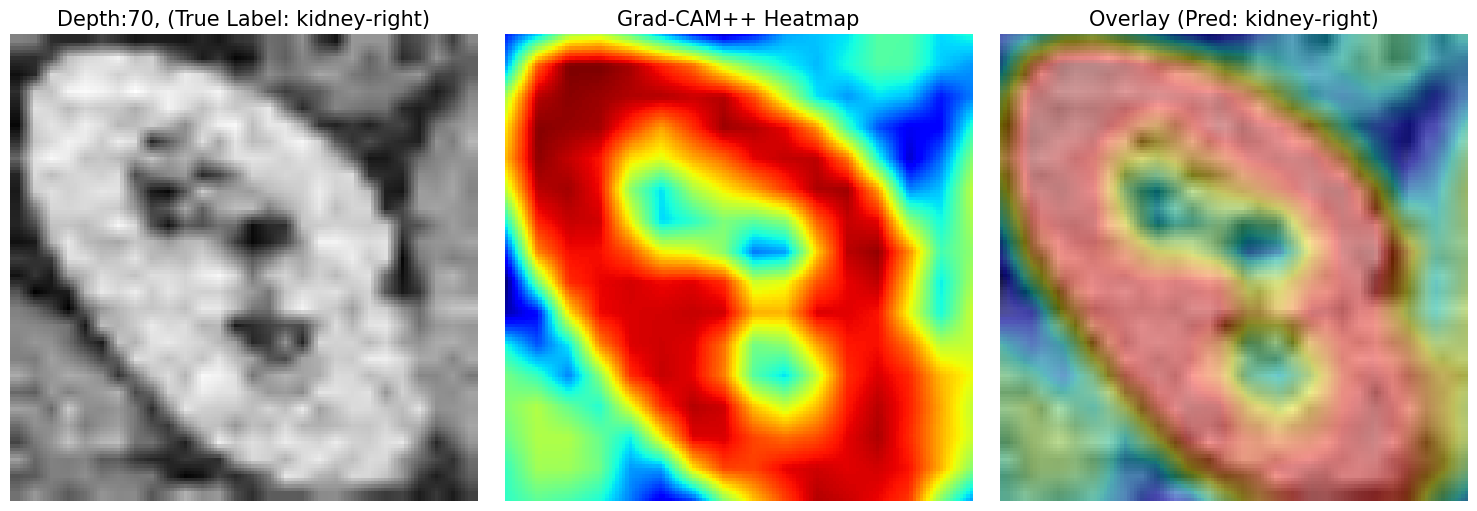

In [102]:
input_img = img_tensor.squeeze().numpy() # [28, 28, 28]
zoom_factors = [i / j for i, j in zip(input_img.shape, heatmap_low_res.shape)]
heatmap_resized = zoom(heatmap_low_res, zoom_factors, order=1)

# 3Dデータの中央スライス（Depth方向の真ん中）を選択して2Dプロット
mid_slice = input_img.shape[0] // 2

plt.figure(figsize=(15, 5))

# 元の画像スライス
plt.subplot(1, 3, 1)
plt.title(f"Depth:{mid_slice}, (True Label: {info['label'][str(label_tensor.item())]})", fontsize=15)
plt.imshow(input_img[mid_slice, :, :], cmap='gray')
plt.axis('off')

# ヒートマップ単体
plt.subplot(1, 3, 2)
plt.title("Grad-CAM++ Heatmap", fontsize=15)
plt.imshow(heatmap_resized[mid_slice, :, :], cmap='jet')
plt.axis('off')

# 重ね合わせ画像
plt.subplot(1, 3, 3)
plt.title(f"Overlay (Pred: {target_label_name})", fontsize=15)
plt.imshow(input_img[mid_slice, :, :], cmap='gray')
plt.imshow(heatmap_resized[mid_slice, :, :], cmap='jet', alpha=0.4) # alphaで透過度調整
plt.axis('off')
# plt.colorbar()
plt.tight_layout()
# plt.savefig(f"Grad-CAM++_2d_test_{target_label_name}")
plt.show()

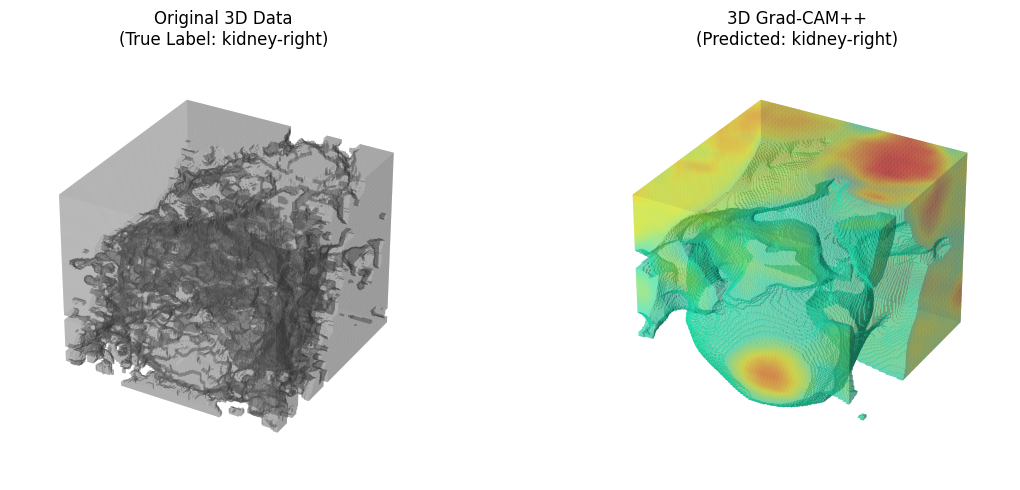

In [103]:
# --- 3Dプロット用の設定 ---
fig = plt.figure(figsize=(12, 5))

# 1. 元の3D画像（値が一定以上のボクセルを可視化）
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.set_title(f"Original 3D Data\n(True Label: {info['label'][str(label_tensor.item())]})")
# 医学用MNISTは背景が0で物体に値があるので、適当な閾値（例: 0.2）以上のボクセルを表示
filled_img = input_img > 0.001
ax1.voxels(filled_img, edgecolor='none', alpha=0.3, facecolors='gray')
ax1.axis('off')

# 2. Grad-CAM++ 3D ヒートマップ
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
# タイトルに予測したラベルの名前を追加
ax2.set_title(f"3D Grad-CAM++\n(Predicted: {target_label_name})")

# ヒートマップの重要度が高いボクセル（例: 上位30%の領域）を抽出して立体化
threshold = 0.4
filled_cam = heatmap_resized > threshold

# ボクセルごとにJetカラーマップの色を割り当てる
cmap = plt.get_cmap('jet')
# heatmap_resizedの値（0-1）をそのままRGBカラーに変換
colors = cmap(heatmap_resized) 

# 3Dプロットの実行（filled_camがTrueの場所だけ、colorsの色で描画）
ax2.voxels(filled_cam, facecolors=colors, edgecolor='none', alpha=0.5)
ax2.axis('off')

plt.tight_layout()
# plt.savefig(f"Grad-CAM++_3d_test_{target_label_name}")
plt.show()

torch.Size([1, 32, 1, 1, 1])


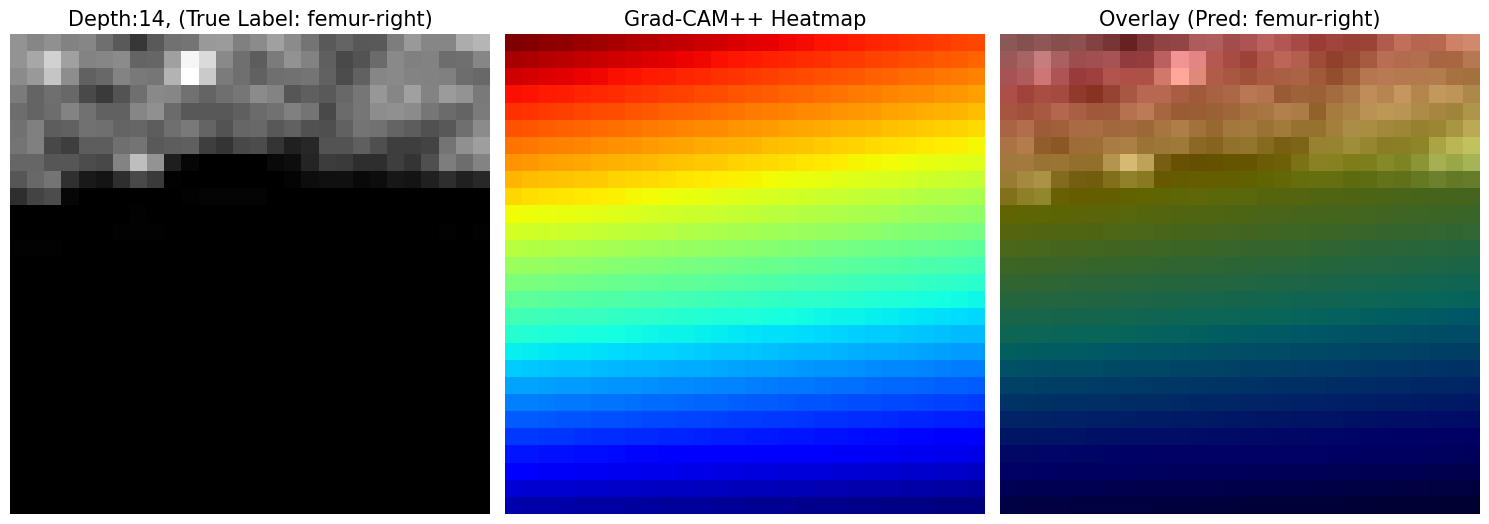

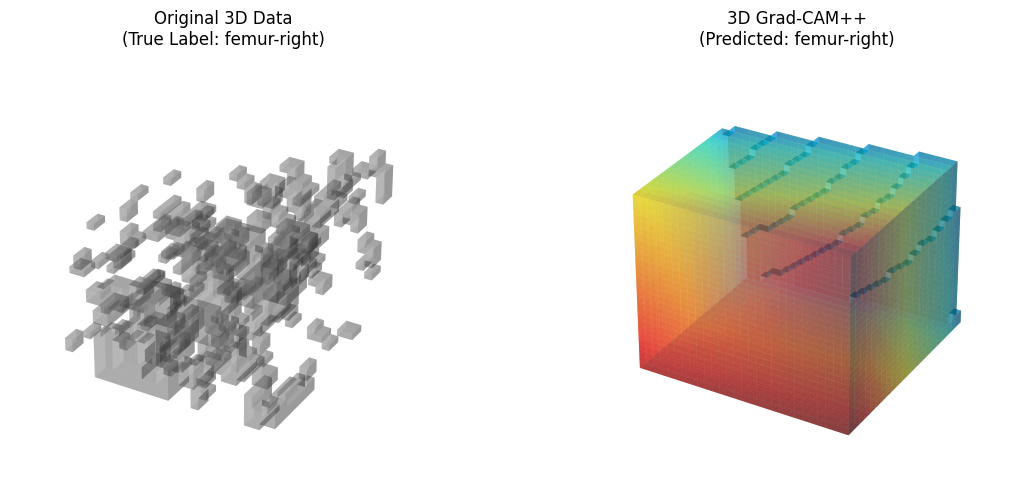

torch.Size([1, 32, 1, 1, 1])


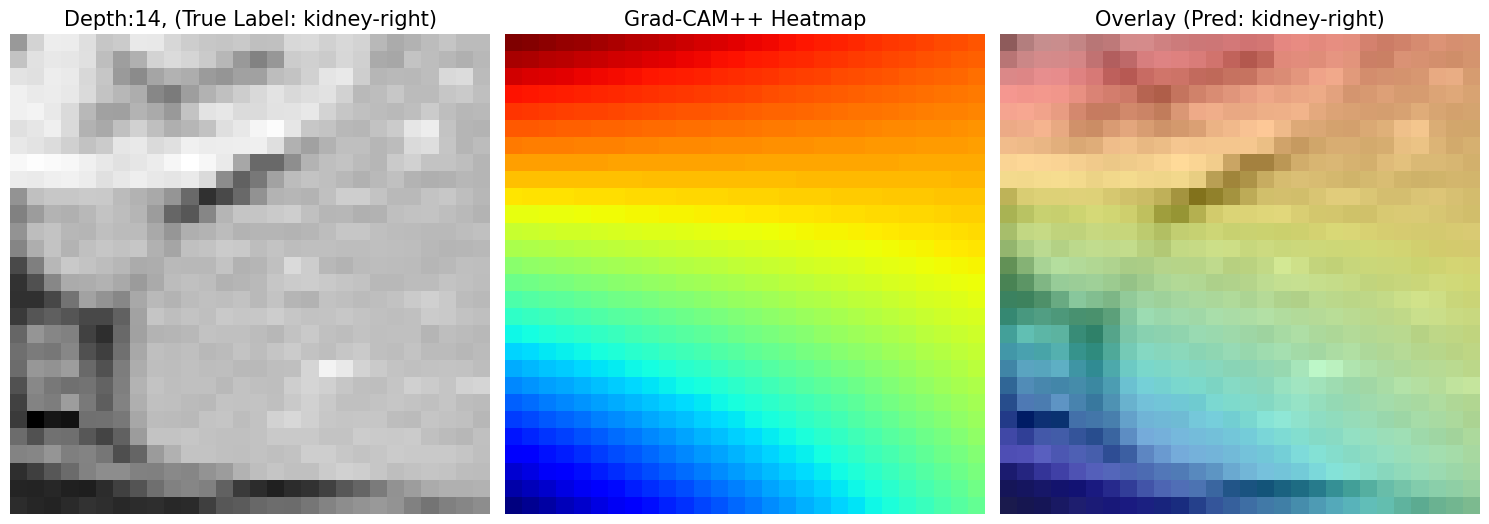

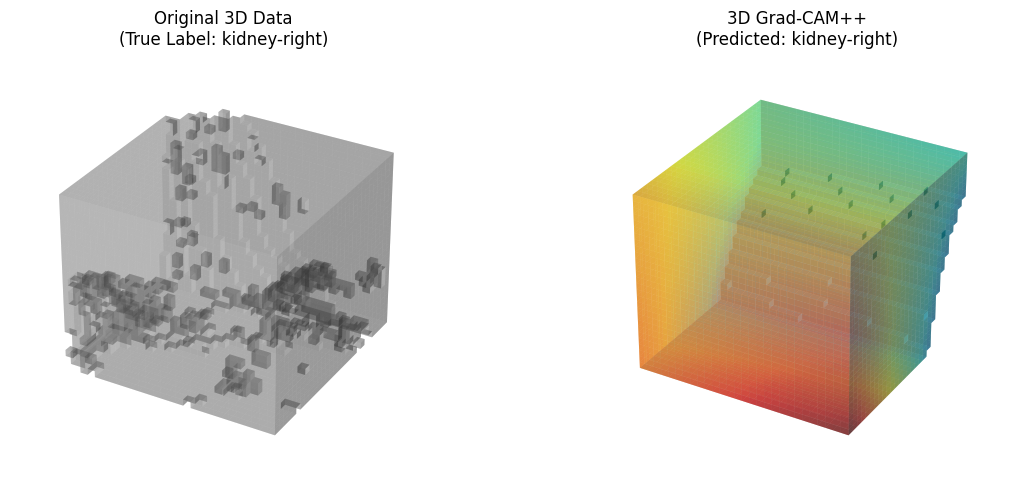

torch.Size([1, 32, 1, 1, 1])


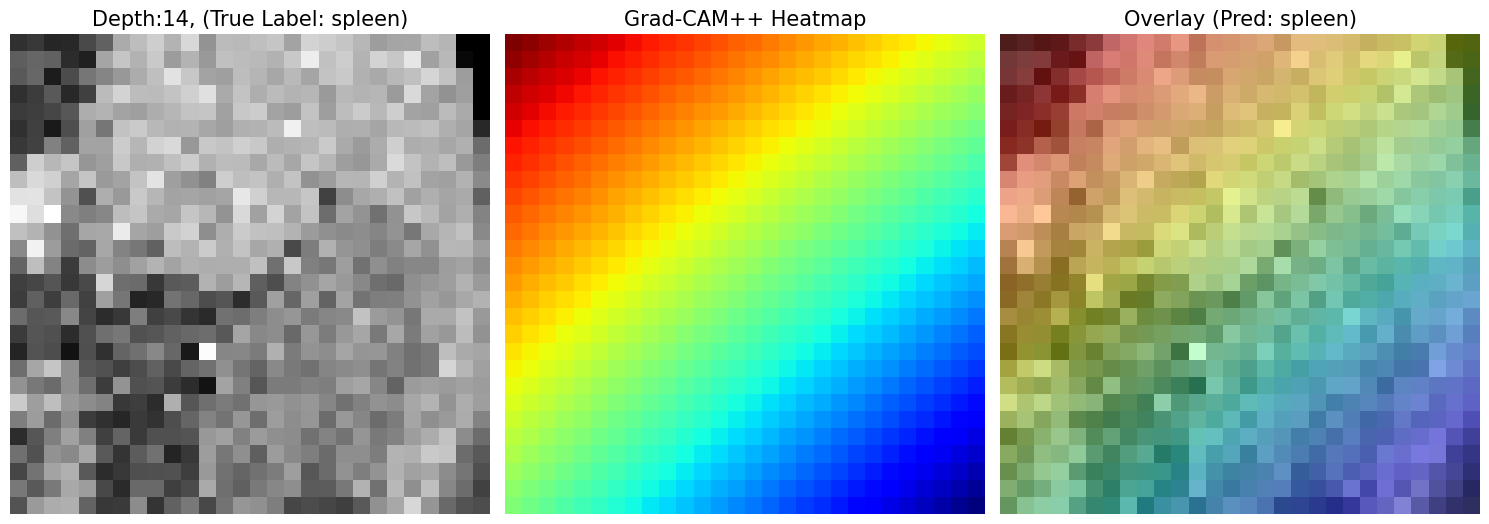

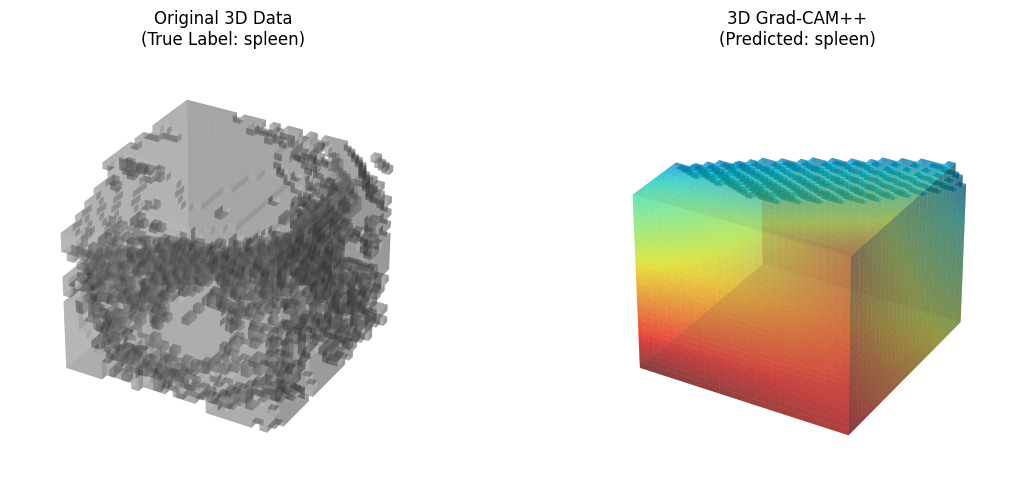

torch.Size([1, 32, 1, 1, 1])


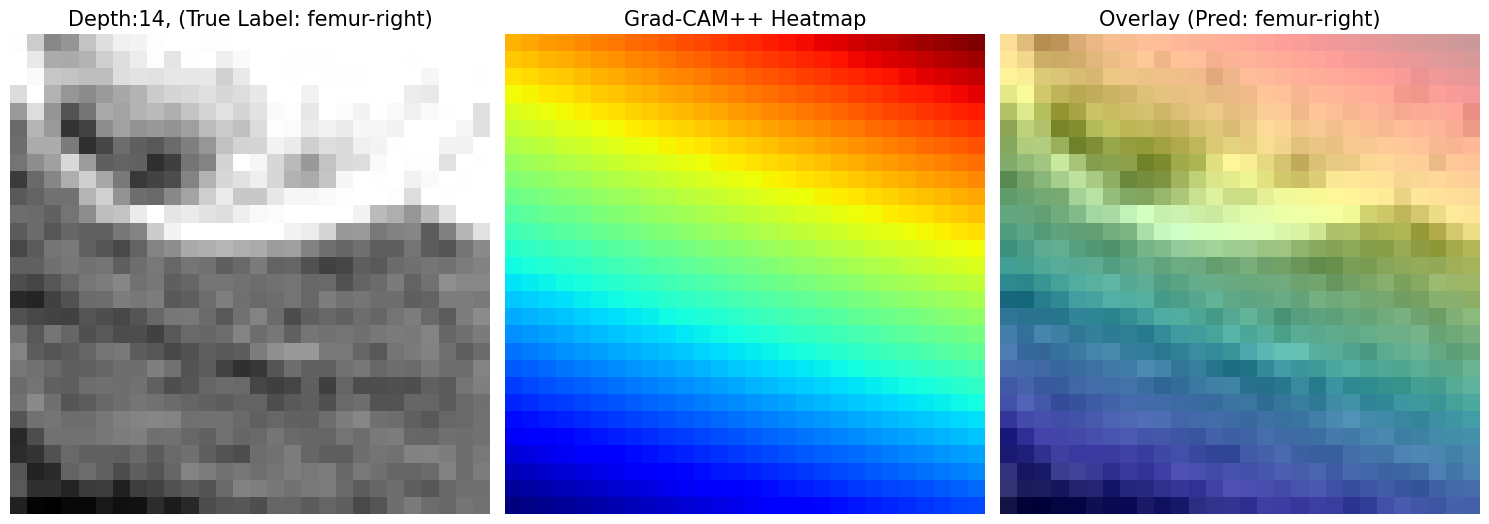

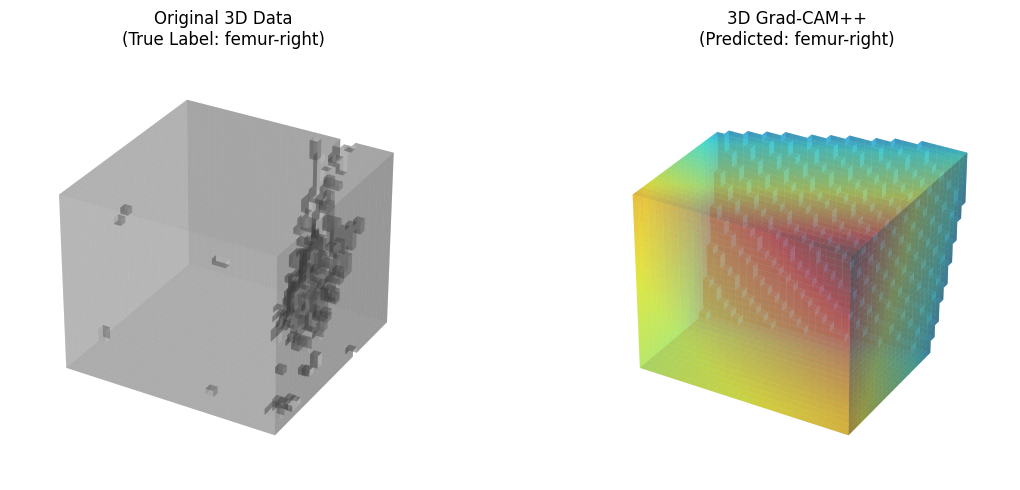

torch.Size([1, 32, 1, 1, 1])


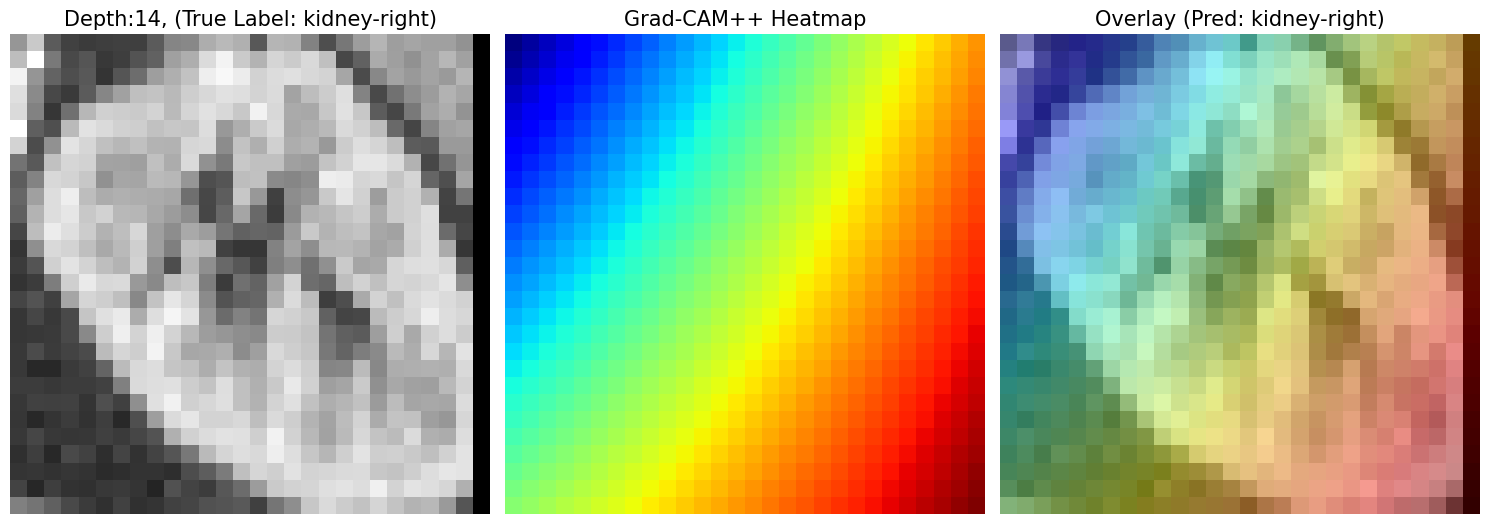

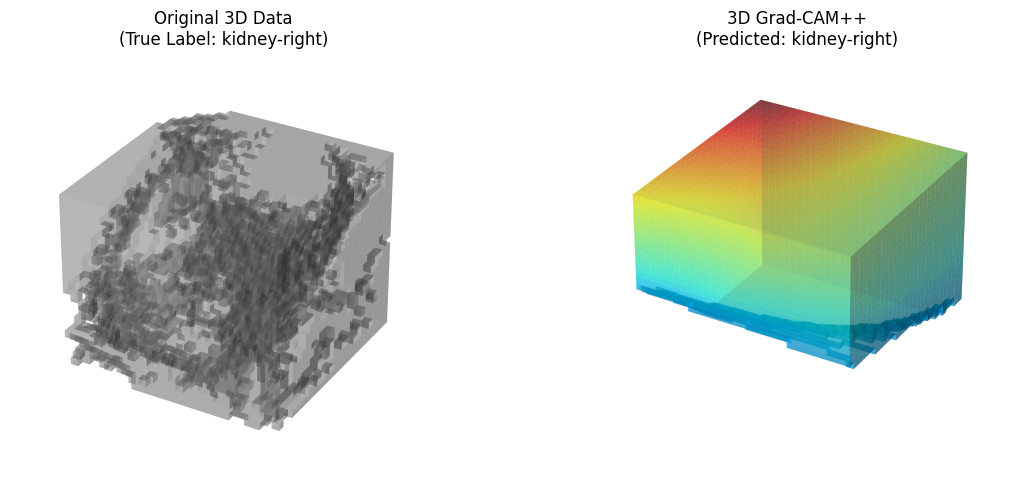

torch.Size([1, 32, 1, 1, 1])


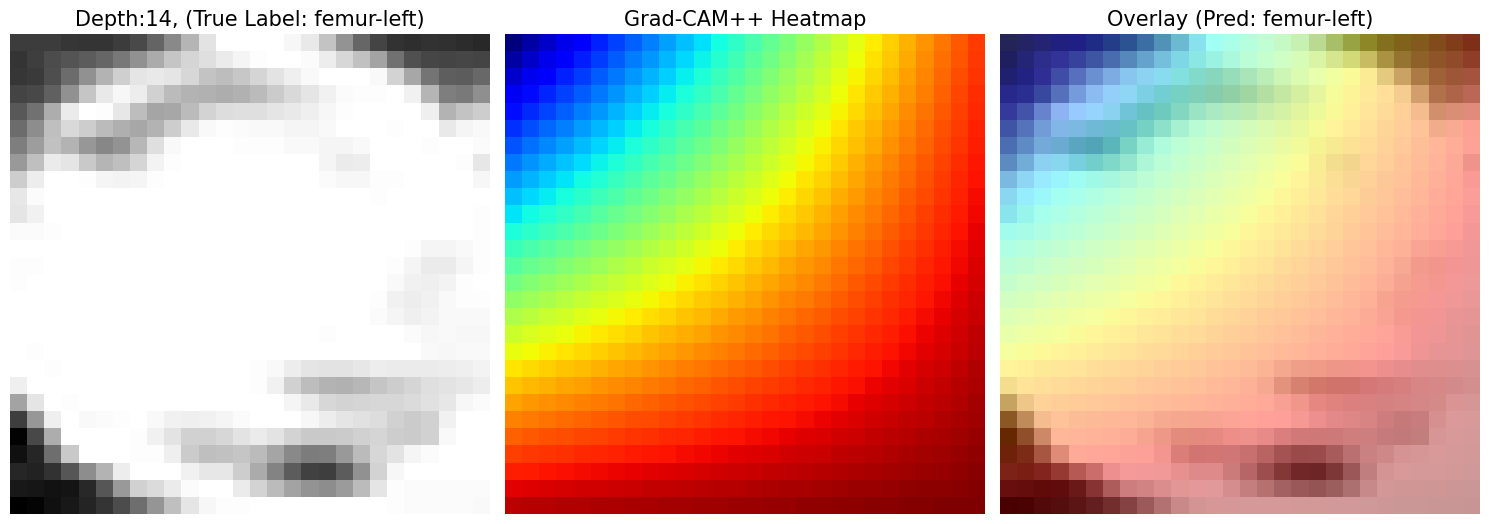

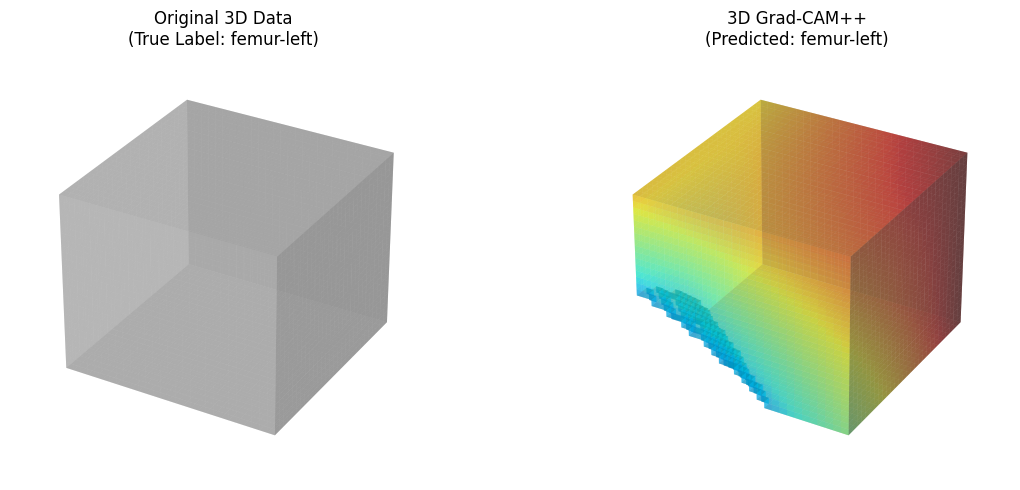

torch.Size([1, 32, 1, 1, 1])


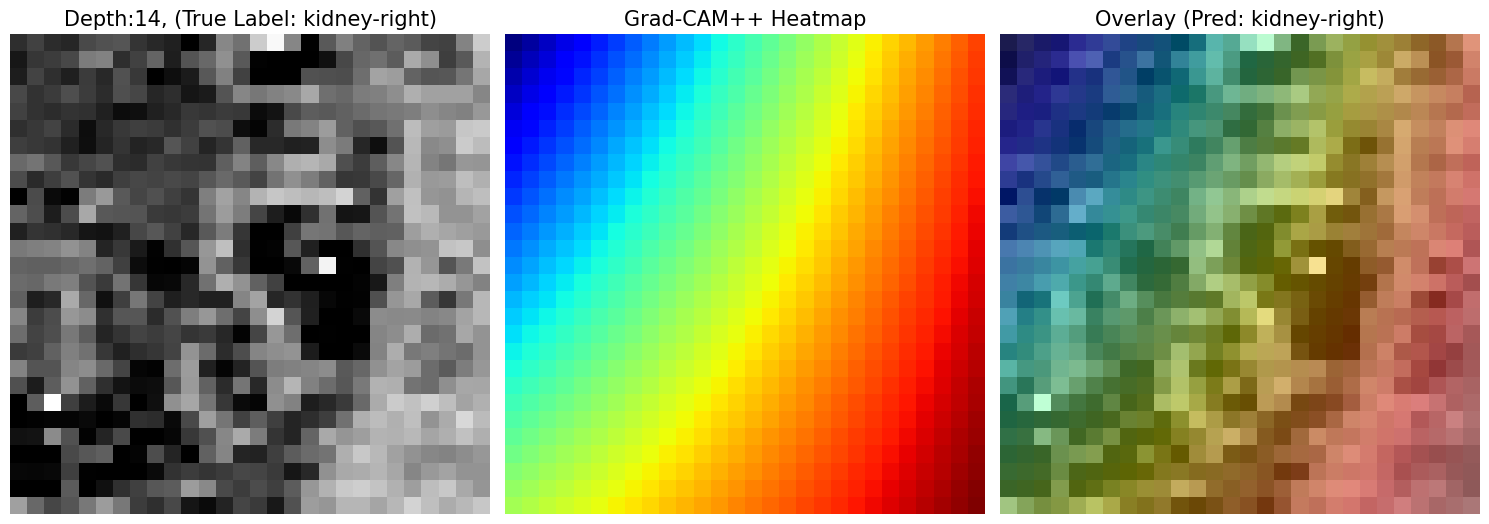

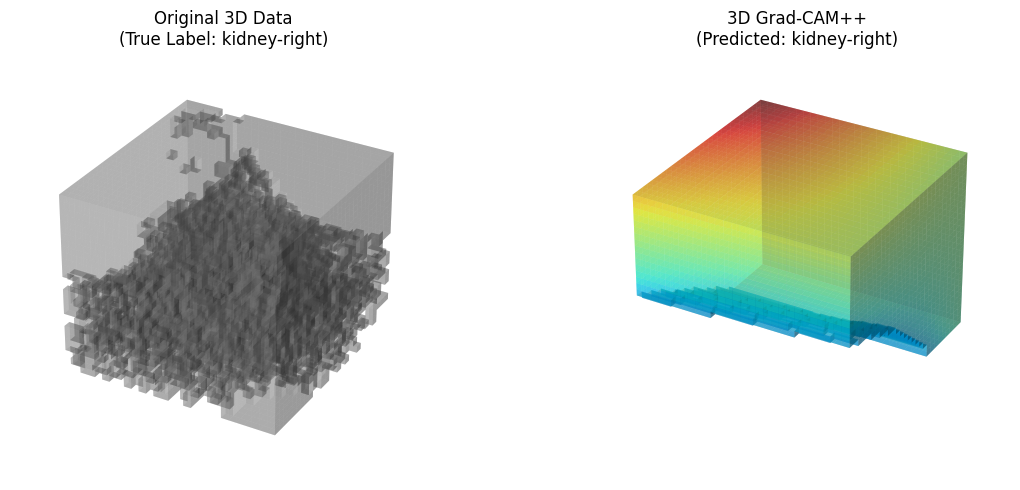

torch.Size([1, 32, 1, 1, 1])


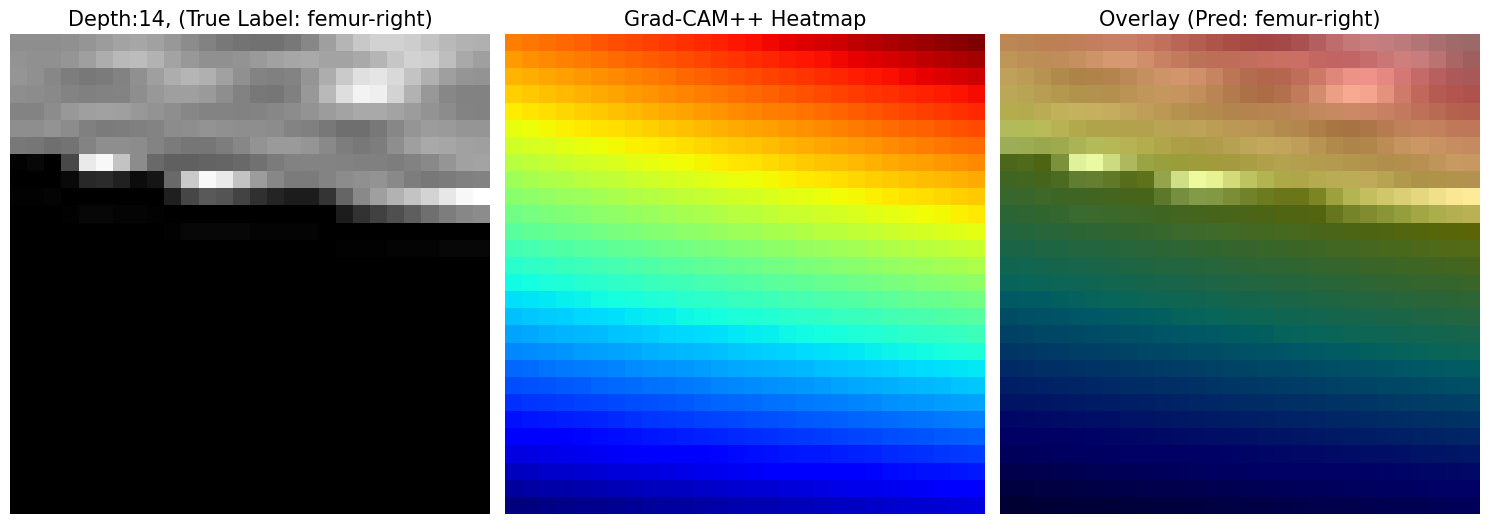

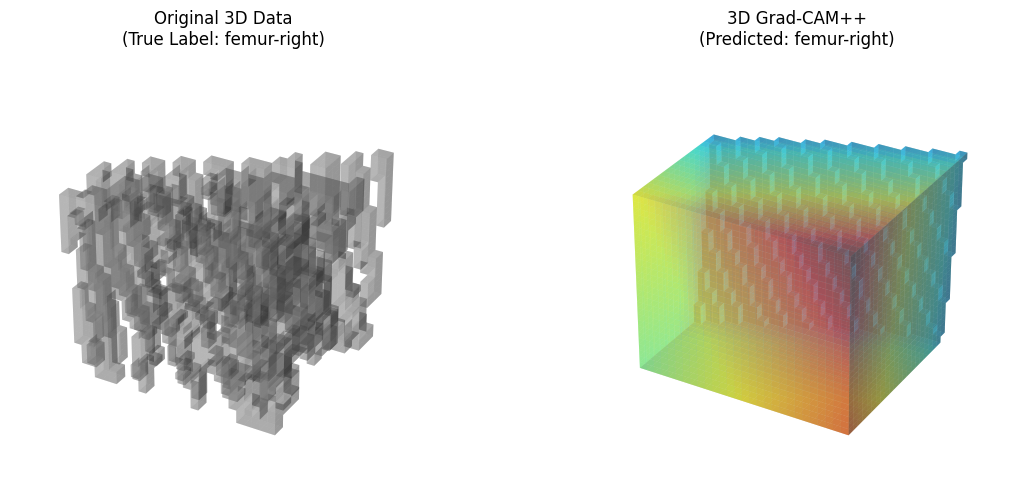

torch.Size([1, 32, 1, 1, 1])


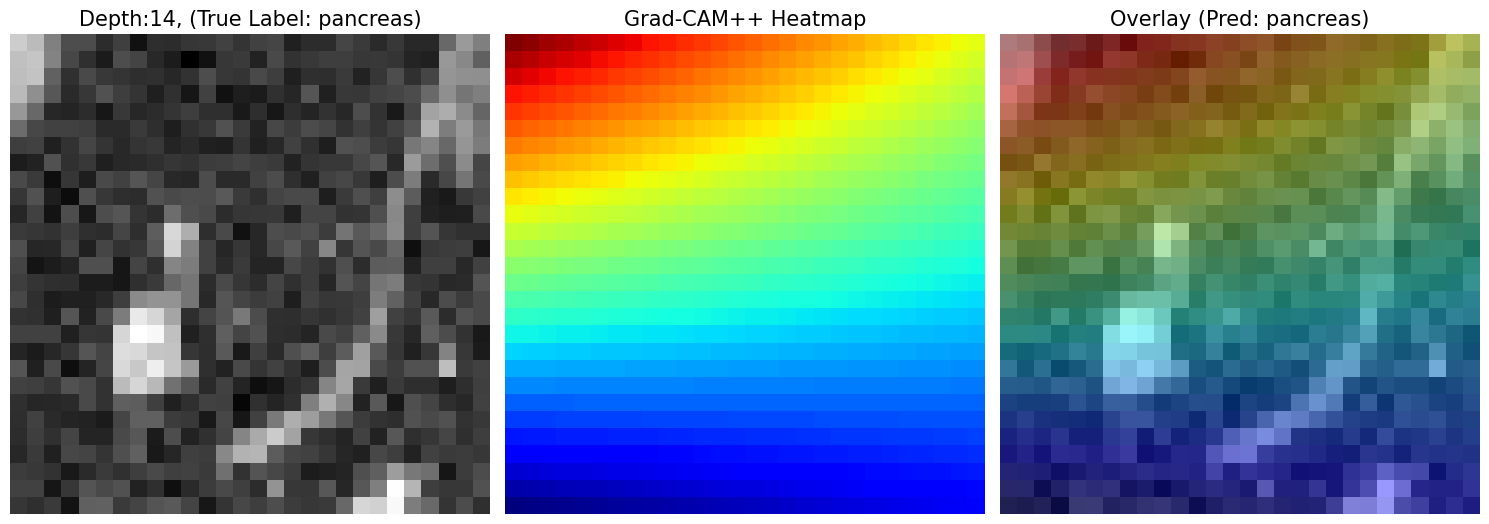

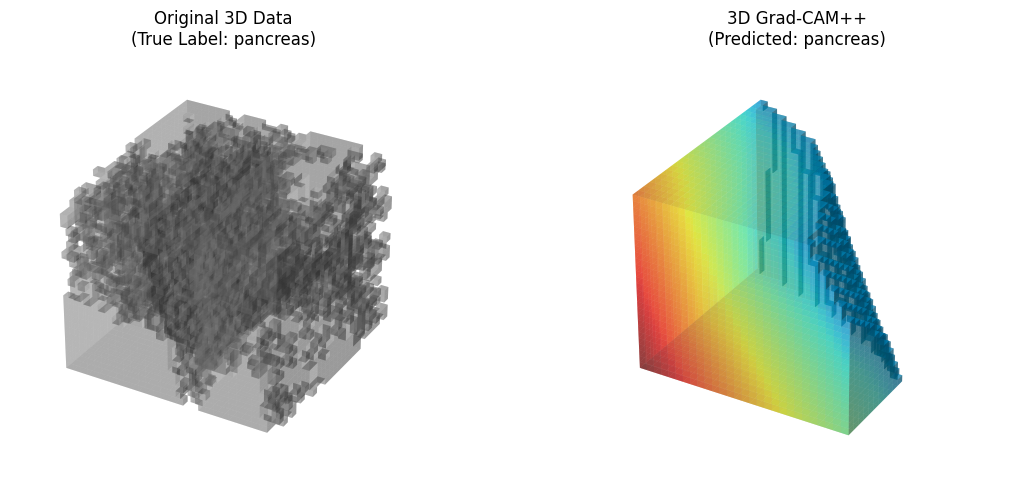

torch.Size([1, 32, 1, 1, 1])


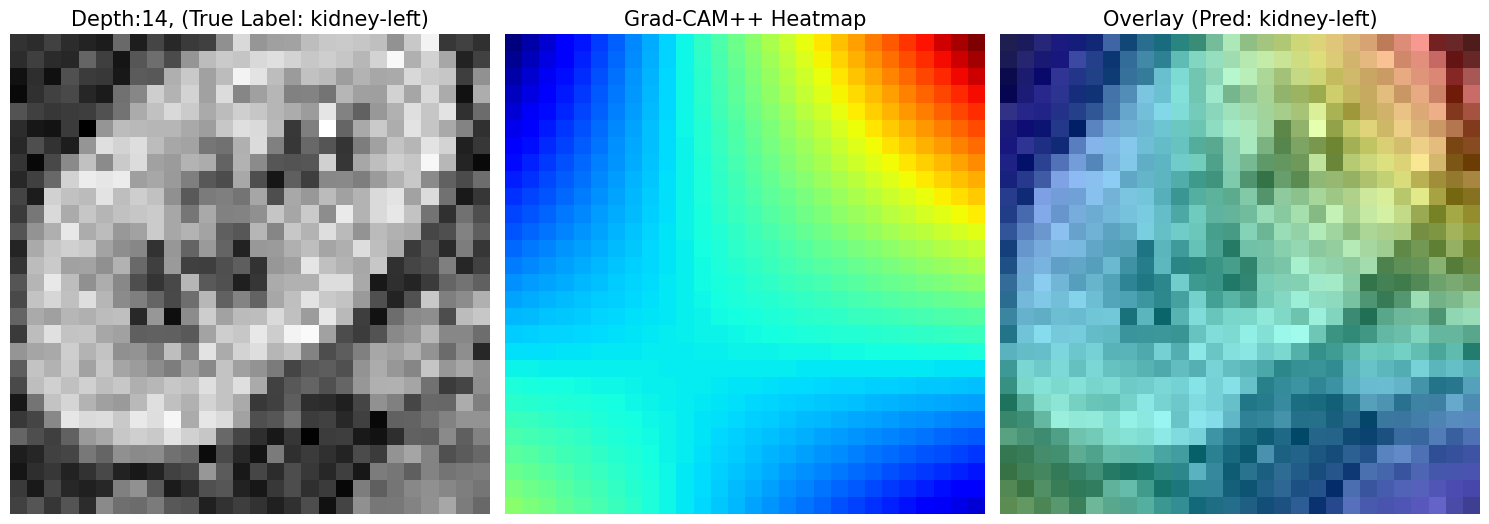

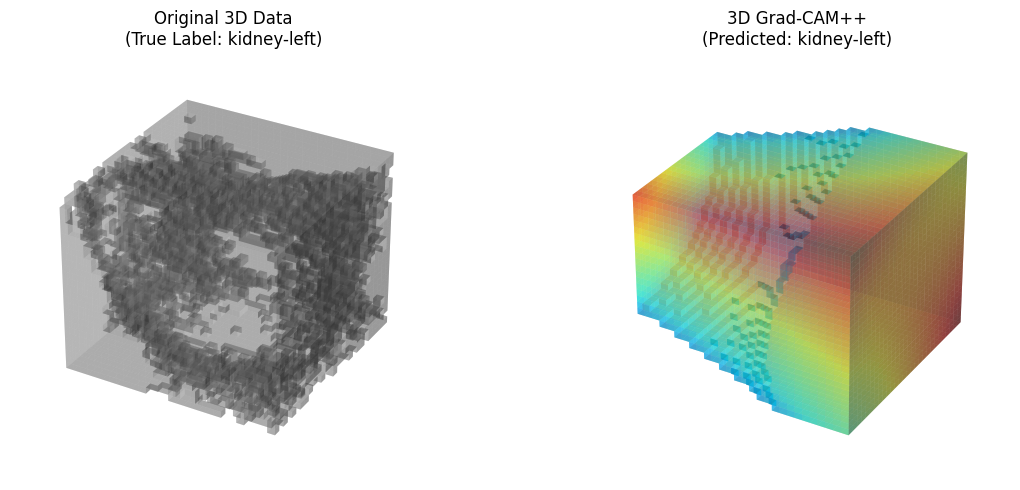

torch.Size([1, 32, 1, 1, 1])


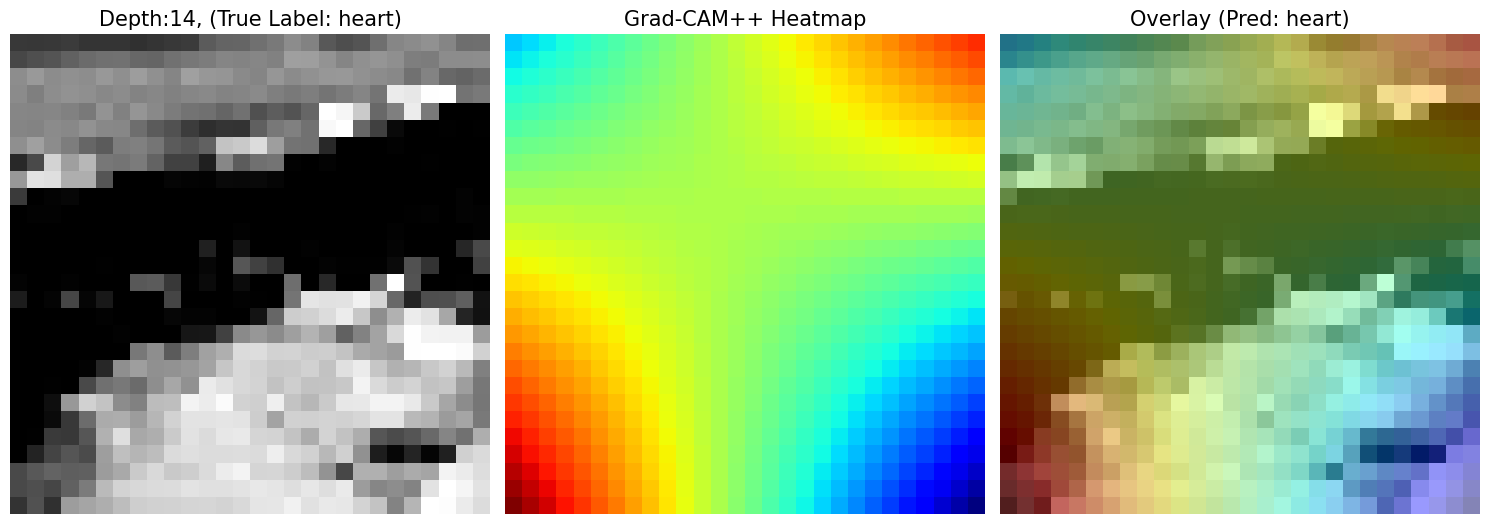

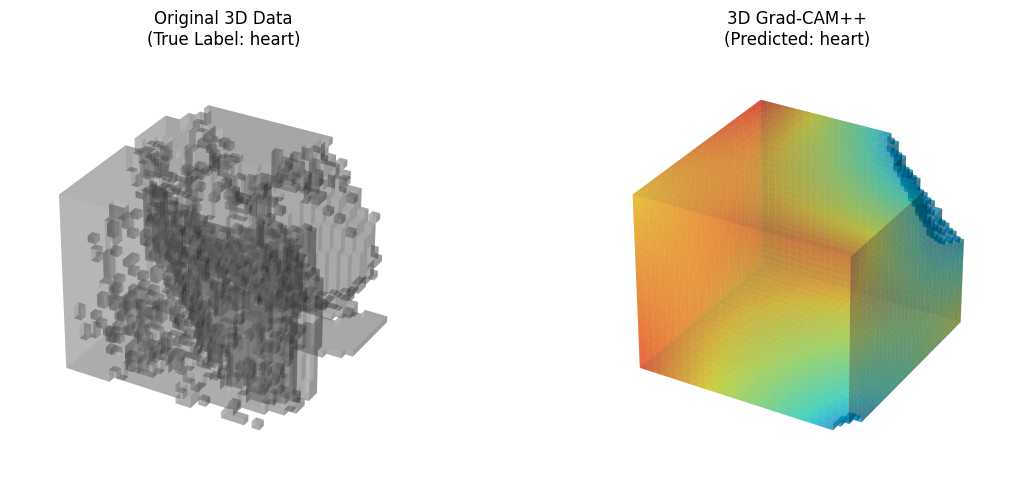

torch.Size([1, 32, 1, 1, 1])


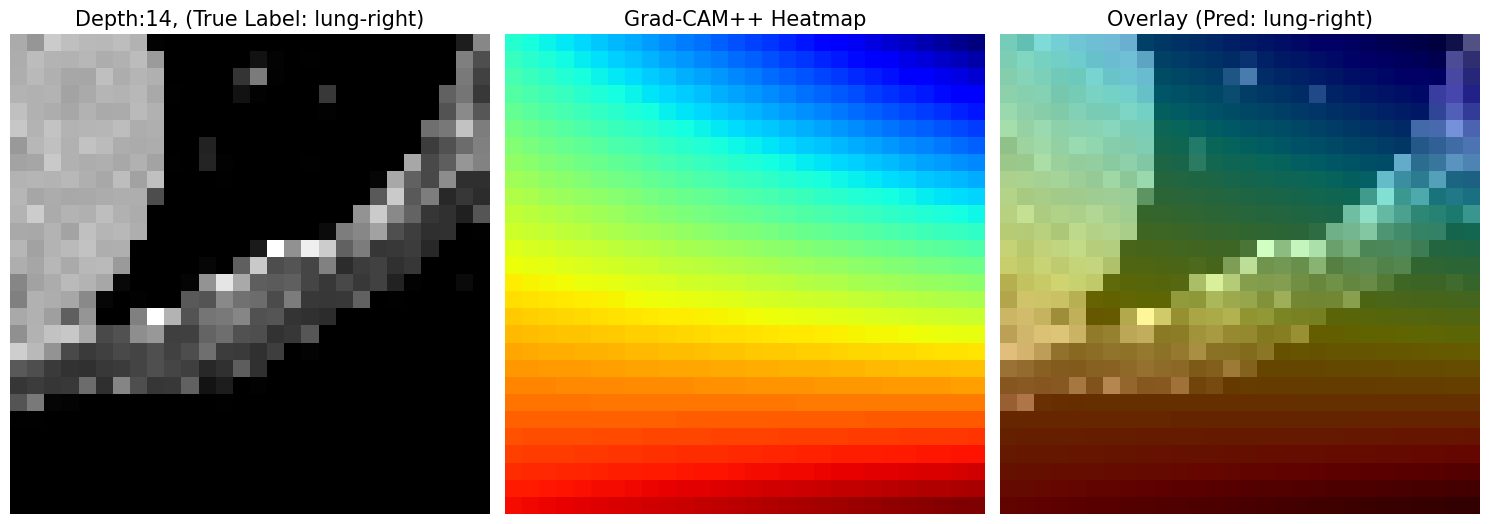

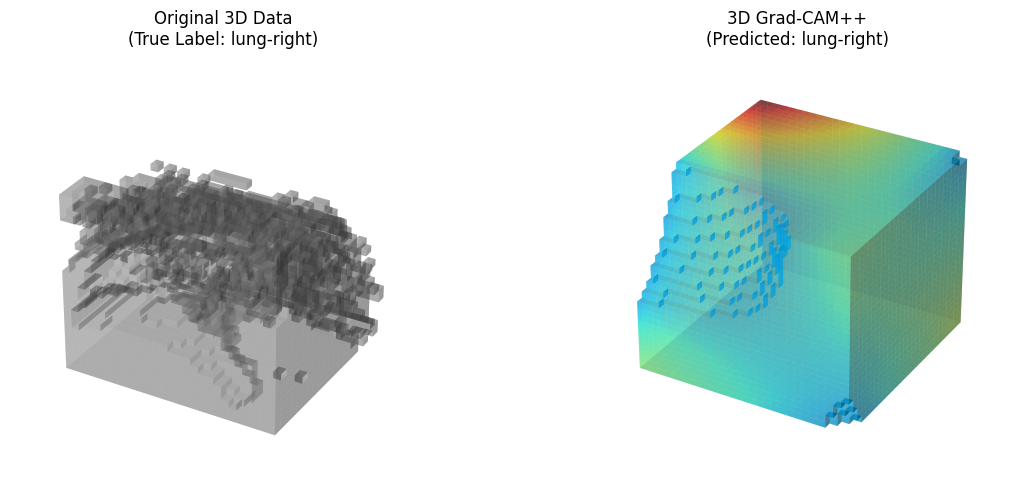

torch.Size([1, 32, 1, 1, 1])


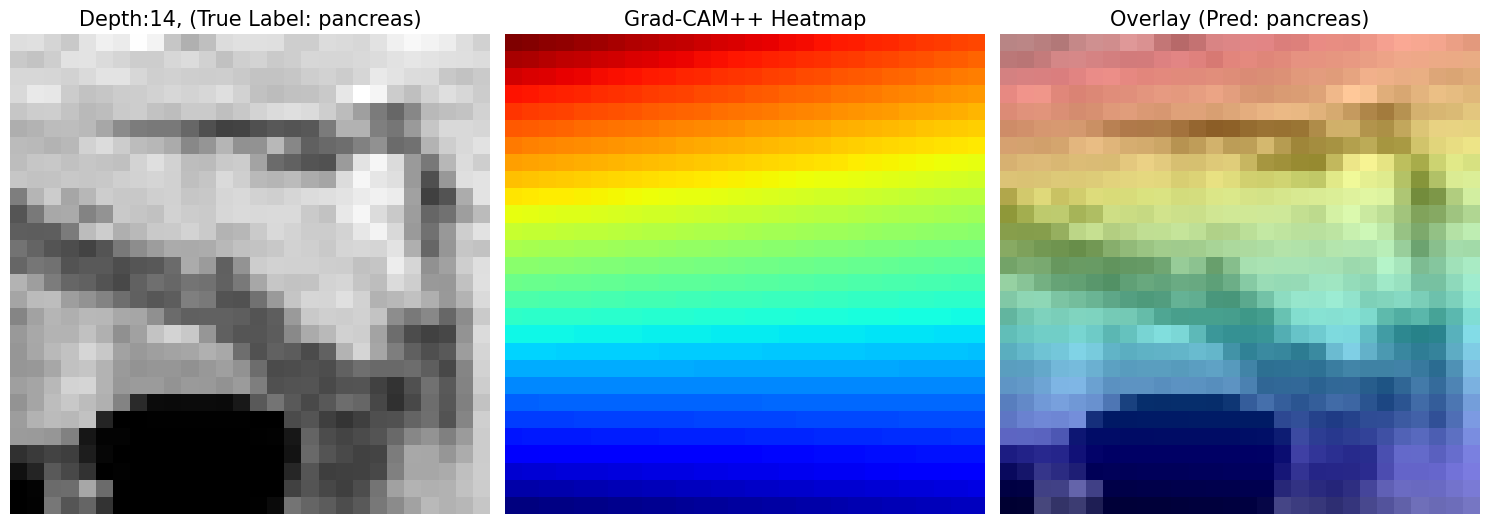

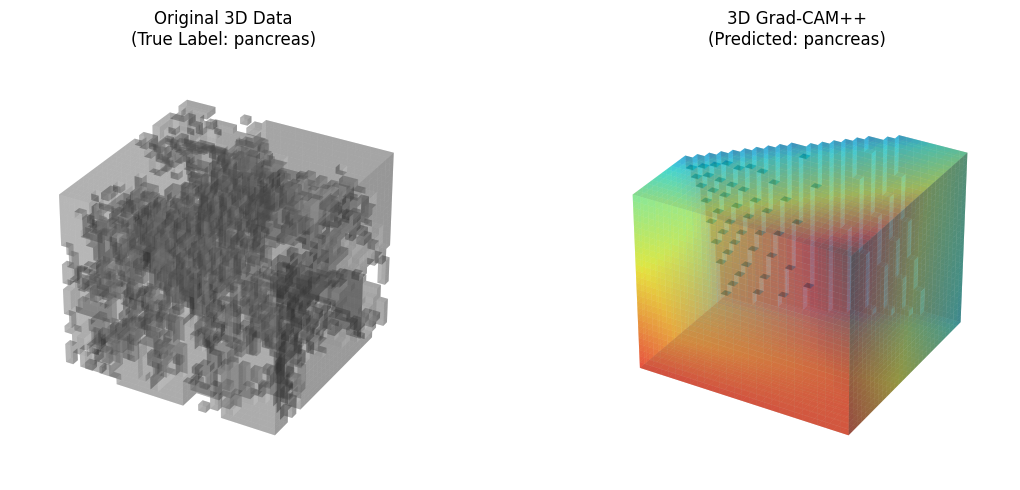

torch.Size([1, 32, 1, 1, 1])


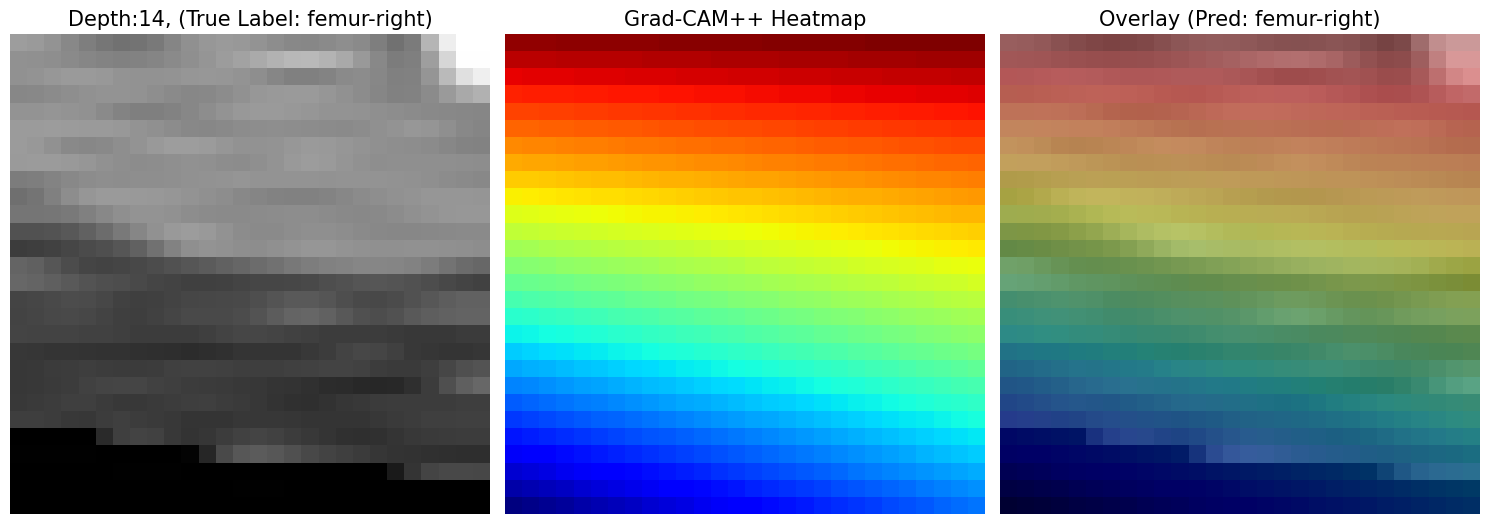

KeyboardInterrupt: 

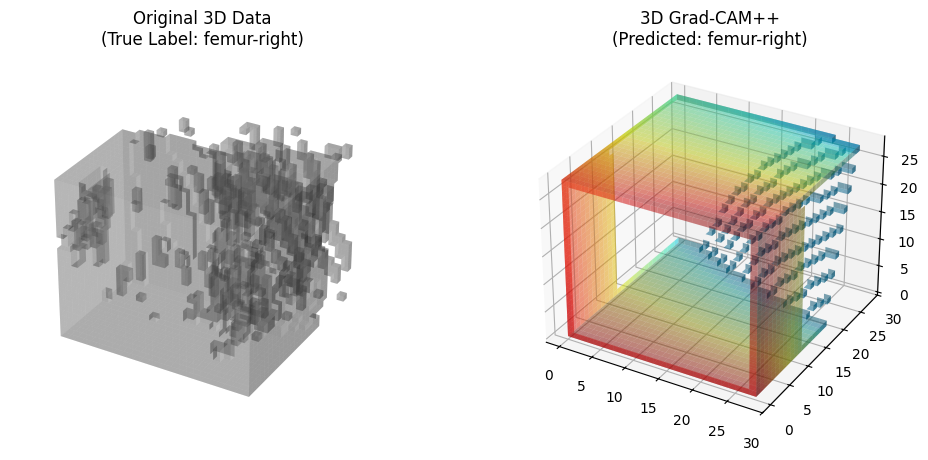

In [22]:
for i in range(30):
    # ==========================================
    # 5. 可視化処理（3D立体プロットとラベル名の追加）
    # ==========================================
    # テストデータから1件抽出
    data_iter = iter(test_loader)
    img_tensor, label_tensor = next(data_iter)
    
    # Grad-CAM++の適用
    cam_generator = GradCAMPlusPlus3D(model, model.target_conv)
    heatmap_low_res, pred_class = cam_generator.generate_cam(img_tensor, label_tensor)
    cam_generator.remove_hooks()
    
    # 低解像度の特徴マップを元の画像サイズ（28x28x28）に拡大
    input_img = img_tensor.squeeze().numpy() # [28, 28, 28]
    zoom_factors = [i / j for i, j in zip(input_img.shape, heatmap_low_res.shape)]
    heatmap_resized = zoom(heatmap_low_res, zoom_factors, order=1)
    
    # --- 【追加】予測されたクラスインデックスから実際のラベル名を取得 ---
    # info['label'] のキーは文字列の数字（'0', '1'..）になっているため str(pred_class) とします
    # print(str(pred_class.item()))
    pred_class =str(pred_class.item())
    target_label_name = info['label'][str(pred_class)]
    
    # 3Dデータの中央スライス（Depth方向の真ん中）を選択して2Dプロット
    mid_slice = input_img.shape[0] // 2
    
    plt.figure(figsize=(15, 6))
    
    # 元の画像スライス
    plt.subplot(1, 3, 1)
    plt.title(f"Depth:{mid_slice}, (True Label: {info['label'][str(label_tensor.item())]})", fontsize=15)
    plt.imshow(input_img[mid_slice, :, :], cmap='gray')
    plt.axis('off')
    
    # ヒートマップ単体
    plt.subplot(1, 3, 2)
    plt.title("Grad-CAM++ Heatmap", fontsize=15)
    plt.imshow(heatmap_resized[mid_slice, :, :], cmap='jet')
    plt.axis('off')
    
    # 重ね合わせ画像
    plt.subplot(1, 3, 3)
    plt.title(f"Overlay (Pred: {target_label_name})", fontsize=15)
    plt.imshow(input_img[mid_slice, :, :], cmap='gray')
    plt.imshow(heatmap_resized[mid_slice, :, :], cmap='jet', alpha=0.4) # alphaで透過度調整
    plt.axis('off')
    # plt.colorbar()
    plt.tight_layout()
    # plt.savefig(f"Grad-CAM++_2d_test_{target_label_name}_change_threshold.png")
    plt.show()
    
    
    # --- 3Dプロット用の設定 ---
    fig = plt.figure(figsize=(12, 5))
    
    # 1. 元の3D画像（値が一定以上のボクセルを可視化）
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.set_title(f"Original 3D Data\n(True Label: {info['label'][str(label_tensor.item())]})")
    # 医学用MNISTは背景が0で物体に値があるので、適当な閾値（例: 0.2）以上のボクセルを表示
    filled_img = input_img > 0.001
    ax1.voxels(filled_img, edgecolor='none', alpha=0.3, facecolors='gray')
    ax1.axis('off')
    
    # 2. Grad-CAM++ 3D ヒートマップ
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    # タイトルに予測したラベルの名前を追加
    ax2.set_title(f"3D Grad-CAM++\n(Predicted: {target_label_name})")
    
    # ヒートマップの重要度が高いボクセル（例: 上位30%の領域）を抽出して立体化
    threshold = 0.3
    filled_cam = heatmap_resized > threshold
    
    # ボクセルごとにJetカラーマップの色を割り当てる
    cmap = plt.get_cmap('jet')
    # heatmap_resizedの値（0-1）をそのままRGBカラーに変換
    colors = cmap(heatmap_resized) 
    
    # 3Dプロットの実行（filled_camがTrueの場所だけ、colorsの色で描画）
    ax2.voxels(filled_cam, facecolors=colors, edgecolor='none', alpha=0.5)
    ax2.axis('off')
    
    plt.tight_layout()
    # plt.savefig(f"Grad-CAM++_3d_test_{target_label_name}_threshold{threshold}.png")
    plt.show()